In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l


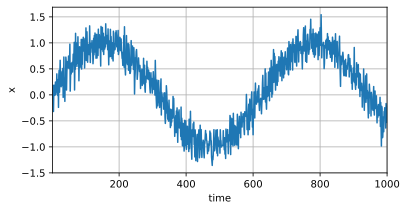

In [4]:
T = 1000 # 总共产生1000个点
time = torch.arange(1, T + 1, dtype=torch.float32) # 1-1000
x = torch.sin(0.01 * time) + torch.normal(0, 0.2, (T,)) #0-999
d2l.plot(time, [x], 'time', 'x', xlim=[1, 1000], figsize=(6, 3))

In [9]:
tau=4
features= torch.zeros((T-tau,tau)) #996行，4列
for i in range(tau):
    features[:,i]=x[i:T-tau+i] #feature的第1，2，3，4列 = x【1】到x[997] 2-998 3-999 4-1000 
labels= x[tau:].reshape((-1,1)) # x 4 到x999 ,只有一列
#最后： feature      lables
#       x0,x1,x2,x3   x4
#       x1,x2,x3,x4   x5

In [10]:
print(features,labels)

tensor([[-0.0183,  0.1684,  0.1855, -0.3195],
        [ 0.1684,  0.1855, -0.3195,  0.0664],
        [ 0.1855, -0.3195,  0.0664,  0.1610],
        ...,
        [-0.2719, -0.3927, -0.6369, -0.1674],
        [-0.3927, -0.6369, -0.1674, -0.2342],
        [-0.6369, -0.1674, -0.2342, -0.5292]]) tensor([[ 6.6377e-02],
        [ 1.6098e-01],
        [ 1.8453e-01],
        [-9.9898e-03],
        [ 1.3513e-01],
        [ 2.4615e-01],
        [ 9.2538e-03],
        [ 4.3816e-02],
        [ 8.0775e-02],
        [ 4.0313e-01],
        [ 1.1990e-01],
        [ 1.5585e-01],
        [-1.3174e-02],
        [ 2.9503e-01],
        [-2.4035e-01],
        [ 3.7359e-01],
        [ 4.7307e-01],
        [ 5.1029e-02],
        [ 3.2255e-01],
        [ 6.6395e-01],
        [ 2.8607e-01],
        [ 1.8259e-01],
        [ 1.5674e-01],
        [ 3.0012e-01],
        [ 4.2178e-01],
        [ 4.5637e-01],
        [ 1.7759e-01],
        [ 5.0782e-01],
        [-4.8430e-02],
        [ 1.3527e-02],
        [ 7.2683e-01

In [13]:
batch_size,n_train=16,600
# 只有前n_train个样本用于训练
train_iter = d2l.load_array((features[:n_train], labels[:n_train]),
batch_size, is_train=True)


In [18]:
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight) #Xavier 初始化（也叫 Glorot 初始化）是一种为神经网络层设置初始权重的方法，目的是让信号在前向传播和反向传播时都能保持稳定，不会太快消失或爆炸。

def get_net():
    net = nn.Sequential(nn.Linear(4,10),
                       nn.ReLU(),
                       nn.Linear(10,1))
    net.apply(init_weights)
    return net

loss = nn.MSELoss(reduction='none')


In [21]:
def train(net,train_iter,lr,epochs,loss):
    trainer = torch.optim.Adam(net.parameters(),lr)
    for epoch in range(epochs):
        for X,y in train_iter:
            trainer.zero_grad()
            l=loss(net(X),y)
            l.sum().backward()
            trainer.step()
        print(f'epoch {epoch + 1}, '
            f'loss: {d2l.evaluate_loss(net, train_iter, loss):f}')

net=get_net()
train(net,train_iter,0.01,5,loss)

            

epoch 1, loss: 0.067202
epoch 2, loss: 0.060016
epoch 3, loss: 0.053186
epoch 4, loss: 0.053271
epoch 5, loss: 0.054368


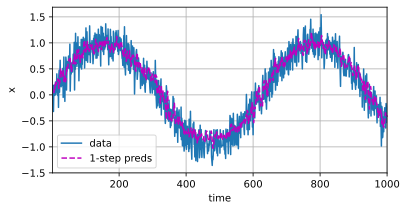

In [22]:
onestep_preds = net(features) 
# 检查模型预测下一个时间步的能力，也就是单步预测（one‐step‐ahead prediction）
d2l.plot([time, time[tau:]],
        [x.detach().numpy(), onestep_preds.detach().numpy()], 'time',
        'x', legend=['data', '1-step preds'], xlim=[1, 1000],
        figsize=(6, 3))


In [23]:
# 对于直到xt的观测序列，其在时间步t + k处的预测输出xˆt+k 称为k步预测（k‐step‐ahead‐prediction）


In [24]:
multistep_preds = torch.zeros(T)
multistep_preds[: n_train + tau] = x[: n_train + tau]
for i in range(n_train + tau, T):
    multistep_preds[i] = net(
        multistep_preds[i - tau:i].reshape((1, -1)))


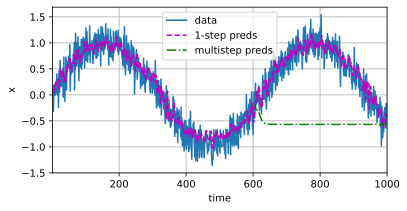

In [25]:
d2l.plot([time, time[tau:], time[n_train + tau:]],
        [x.detach().numpy(), onestep_preds.detach().numpy(),
        multistep_preds[n_train + tau:].detach().numpy()], 'time',
        'x', legend=['data', '1-step preds', 'multistep preds'],
        xlim=[1, 1000], figsize=(6, 3))

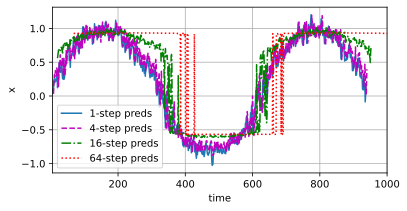

In [26]:
max_steps = 64
features = torch.zeros((T - tau - max_steps + 1, tau + max_steps))
# 列i（i<tau）是来自x的观测，其时间步从（i）到（i+T-tau-max_steps+1）
for i in range(tau):
    features[:, i] = x[i: i + T - tau - max_steps + 1]

# 列i（i>=tau）是来自（i-tau+1）步的预测，其时间步从（i）到（i+T-tau-max_steps+1）
for i in range(tau, tau + max_steps):
    features[:, i] = net(features[:, i - tau:i]).reshape(-1)
steps = (1, 4, 16, 64)
d2l.plot([time[tau + i - 1: T - max_steps + i] for i in steps],
    [features[:, (tau + i - 1)].detach().numpy() for i in steps], 'time', 'x',
    legend=[f'{i}-step preds' for i in steps], xlim=[5, 1000],
    figsize=(6, 3))